In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [3]:
df = pd.read_csv("../Datasets/mutual_funds_india.csv")

In [4]:
df.head()

,Unnamed: 0,AMC_name,Mutual Fund Name,category,risk_type,fund_rating,return_1yr,return_3yr,return_5yr
0,0,Quant,Quant Small Cap Fund Direct Plan Growth,Equity,Very High Risk,4.0,9.98,54.37,22.73
1,1,Canara,Canara Robeco Small Cap Fund Direct Growth,Equity,Very High Risk,5.0,20.09,44.48,NaN
2,2,PGIM,PGIM India Midcap Opportunities Fund Direct Gr...,Equity,Very High Risk,5.0,11.02,44.22,21.49
3,3,Bank,Bank of India Small Cap Fund Direct Growth,Equity,Very High Risk,5.0,13.16,44.13,NaN
4,4,Quant,Quant Tax Plan Direct Growth,Equity,Very High Risk,5.0,17.43,43.88,23.76


In [5]:
df.columns

Index(['Unnamed: 0', 'AMC_name', 'Mutual Fund Name', 'category', 'risk_type',
       'fund_rating', 'return_1yr', 'return_3yr', 'return_5yr'],
      dtype='str')

In [6]:
df = df.drop(["Unnamed: 0"], axis = 1)

In [7]:
df.columns

Index(['AMC_name', 'Mutual Fund Name', 'category', 'risk_type', 'fund_rating',
       'return_1yr', 'return_3yr', 'return_5yr'],
      dtype='str')

In [8]:
df.isnull().sum()

AMC_name              0
Mutual Fund Name      0
category              0
risk_type             0
fund_rating         347
return_1yr          113
return_3yr          259
return_5yr          392
dtype: int64

In [9]:
df.fund_rating  = df.fund_rating .fillna(0)

In [10]:
df.return_1yr  = df.return_1yr .fillna(0)

In [11]:
df.return_3yr = df.return_3yr .fillna(0)

In [12]:
df.return_5yr = df.return_5yr .fillna(0)

In [13]:
df.isnull().sum()

AMC_name            0
Mutual Fund Name    0
category            0
risk_type           0
fund_rating         0
return_1yr          0
return_3yr          0
return_5yr          0
dtype: int64

In [14]:
df.dtypes

AMC_name                str
Mutual Fund Name        str
category                str
risk_type               str
fund_rating         float64
return_1yr          float64
return_3yr          float64
return_5yr          float64
dtype: object

In [15]:
df = df.rename(columns={'Mutual Fund Name': 'Mutual_Fund_Name'})

In [16]:
df.columns

Index(['AMC_name', 'Mutual_Fund_Name', 'category', 'risk_type', 'fund_rating',
       'return_1yr', 'return_3yr', 'return_5yr'],
      dtype='str')

In [17]:
df.Mutual_Fund_Name.unique()

<ArrowStringArray>
[              'Quant Small Cap Fund Direct Plan Growth',
            'Canara Robeco Small Cap Fund Direct Growth',
    'PGIM India Midcap Opportunities Fund Direct Growth',
            'Bank of India Small Cap Fund Direct Growth',
                          'Quant Tax Plan Direct Growth',
               'Quant Infrastructure Fund Direct Growth',
                      'Quant Mid Cap Fund Direct Growth',
                    'Quant Flexi Cap Fund Direct Growth',
                       'Quant Active Fund Direct Growth',
                    'Kotak Small Cap Fund Direct Growth',
 ...
 'Axis CRISIL IBX SDL May 2027 Index Fund Direct Growth',
                   'ITI Dynamic Bond Fund Direct Growth',
             'ITI Balanced Advantage Fund Direct Growth',
          'Sundaram Ultra Short Term Fund Direct Growth',
                      'ITI Arbitrage Fund Direct Growth',
              'BHARAT Bond FOF April 2025 Direct Growth',
              'BNP Paribas Overnight Fund Direct

In [18]:
df.category.unique()

<ArrowStringArray>
['Equity', 'Hybrid', 'Other', 'Solution Oriented', 'Debt']
Length: 5, dtype: str

In [19]:
df.risk_type.unique()

<ArrowStringArray>
[      'Very High Risk', 'Moderately High Risk',            'High Risk',
        'Moderate Risk', 'Low to Moderate Risk',  'Moderately Low Risk',
             'Low Risk']
Length: 7, dtype: str

In [20]:
df.Mutual_Fund_Name.value_counts()

Mutual_Fund_Name
Mirae Asset Balanced Advantage Fund Direct Growth                   2
SBI Retirement Benefit Fund Aggressive Hybrid Plan Direct Growth    2
HDFC Developed World Indexes FoF Direct Growth                      2
Nippon India Silver ETF FoF Direct Growth                           2
Invesco India Invesco EQQQ NASDAQ 100 ETF FoF Direct Growth         2
                                                                   ..
BHARAT Bond FOF April 2025 Direct Growth                            1
BNP Paribas Overnight Fund Direct Growth                            1
Invesco India Overnight Fund Direct Growth                          1
HSBC Ultra Short Duration Fund Direct Growth                        1
ITI Overnight Fund Direct Growth                                    1
Name: count, Length: 1068, dtype: int64

In [21]:
df.category.value_counts()

category
Equity               380
Debt                 332
Other                214
Hybrid               137
Solution Oriented     25
Name: count, dtype: int64

In [22]:
df.risk_type.value_counts()

risk_type
Very High Risk          571
Moderate Risk           157
Low to Moderate Risk    155
Moderately High Risk     94
Low Risk                 61
High Risk                42
Moderately Low Risk       8
Name: count, dtype: int64

In [23]:
df.describe()

,fund_rating,return_1yr,return_3yr,return_5yr
count,1088.000000,1088.000000,1088.000000,1088.000000
mean,2.088235,3.771480,10.334825,6.103520
std,1.694607,7.875254,9.763274,5.761244
min,0.000000,-39.000000,-9.240000,-2.950000
25%,0.000000,1.090000,2.700000,0.000000
50%,2.000000,3.420000,6.645000,6.000000
75%,3.000000,5.150000,18.042500,10.327500
max,5.000000,78.290000,54.370000,28.910000


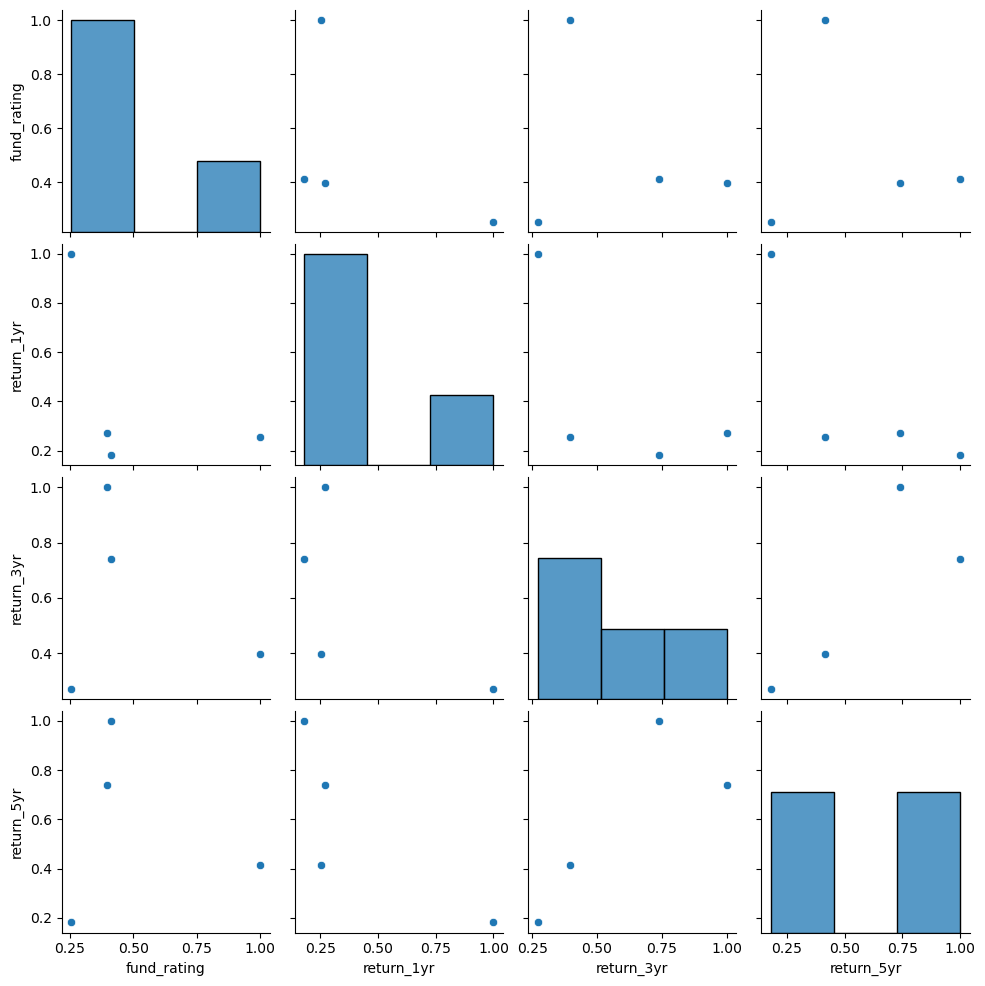

In [24]:
c = df.corr(numeric_only=True)
sb.pairplot(c)
plt.show()

In [25]:
df.groupby('category')['return_1yr'].mean()

category
Debt                 3.655090
Equity               5.727974
Hybrid               4.519051
Other               -0.090374
Solution Oriented    4.539200
Name: return_1yr, dtype: float64

In [26]:
df.groupby('category')['return_3yr'].mean()

category
Debt                  4.649247
Equity               18.024132
Hybrid               10.570584
Other                 5.473738
Solution Oriented     9.280800
Name: return_3yr, dtype: float64

In [27]:
df.groupby('category')['return_5yr'].mean()

category
Debt                 4.340090
Equity               9.078553
Hybrid               6.243942
Other                3.701495
Solution Oriented    4.093200
Name: return_5yr, dtype: float64

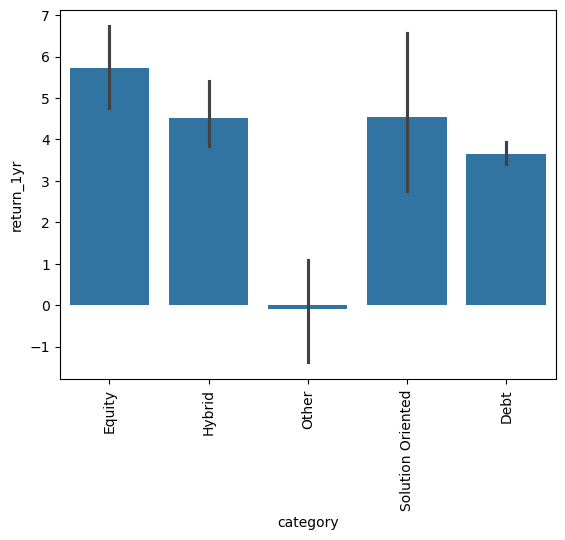

In [28]:
sb.barplot(x=df.category , y=df.return_1yr)
plt.xticks(rotation=90)
plt.show()

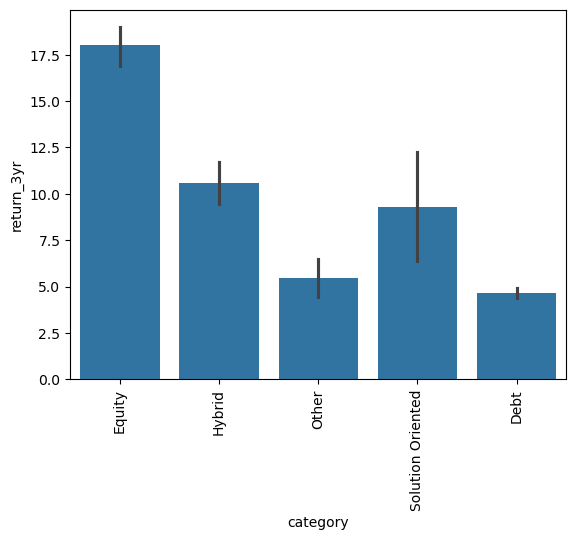

In [29]:
sb.barplot(x=df.category , y=df.return_3yr)
plt.xticks(rotation=90)
plt.show()

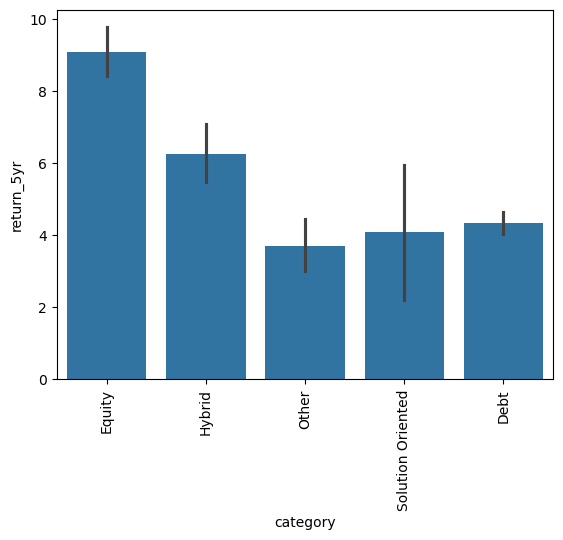

In [30]:
sb.barplot(x=df.category , y=df.return_5yr)
plt.xticks(rotation=90)
plt.show()

In [31]:
df.groupby('risk_type')['return_5yr'].mean()

risk_type
High Risk               6.202143
Low Risk                1.873607
Low to Moderate Risk    4.451548
Moderate Risk           4.648471
Moderately High Risk    4.249043
Moderately Low Risk     1.641250
Very High Risk          7.764466
Name: return_5yr, dtype: float64

In [32]:
df.groupby('AMC_name')['return_3yr'].mean()

AMC_name
Aditya         9.836190
Axis           6.824667
BHARAT         0.000000
BNP            8.903333
BOI            4.770000
Bank          14.340714
Baroda        10.212727
Canara        12.827619
DSP           11.373810
Edelweiss      9.556774
Franklin      13.141333
HDFC          10.621277
HSBC           8.867600
ICICI         11.058718
IDBI          15.014762
IDFC           8.330244
IIFL           8.770000
ITI            1.015882
Indiabulls     9.582222
Invesco        9.847059
JM             9.942667
Kotak         10.143095
L&T           11.105517
LIC           10.591053
Mahindra       9.166316
Mirae          8.155000
Motilal        6.072609
NJ             0.000000
Navi           6.518235
Nippon         9.869630
PGIM           8.864091
Parag         13.762500
Principal      8.242500
Quant         24.542500
Quantum       10.778889
Reliance      10.270000
SBI           11.807000
Samco          0.000000
Shriram       10.405000
Sundaram      13.661563
TRUSTMF        0.000000
Tata   

In [33]:
df.groupby('Mutual_Fund_Name')['return_5yr'].mean().nlargest(10)

Mutual_Fund_Name
Tata Digital India Fund Direct Growth                     28.91
ICICI Prudential Technology Direct Plan Growth            28.00
Aditya Birla Sun Life Digital India Fund Direct Growth    27.02
SBI Technology Opportunities Fund Direct Growth           25.85
Quant Infrastructure Fund Direct Growth                   23.91
Quant Tax Plan Direct Growth                              23.76
Quant Active Fund Direct Growth                           23.40
Quant Small Cap Fund Direct Plan Growth                   22.73
Quant Mid Cap Fund Direct Growth                          22.03
PGIM India Midcap Opportunities Fund Direct Growth        21.49
Name: return_5yr, dtype: float64

In [34]:
pd.pivot_table(df,index ='category' ,columns ='risk_type',values ='return_3yr',aggfunc='mean')

risk_type,High Risk,Low Risk,Low to Moderate Risk,Moderate Risk,Moderately High Risk,Moderately Low Risk,Very High Risk
category,,,,,,,
Debt,6.390000,2.923590,4.597483,5.209675,6.306154,2.43,-2.820000
Equity,18.468571,NaN,NaN,NaN,10.497143,NaN,18.308997
Hybrid,8.741429,4.230455,9.206667,7.796000,9.796316,0.00,14.837636
Other,8.820833,NaN,0.000000,1.966957,8.690000,NaN,5.378993
Solution Oriented,13.450000,NaN,NaN,4.510000,7.568750,NaN,13.280000


In [35]:
pd.pivot_table(df,index = 'AMC_name' , columns = 'category' ,values = 'return_5yr' , aggfunc='count')

category,Debt,Equity,Hybrid,Other,Solution Oriented
AMC_name,,,,,
Aditya,13.0,23.0,5.0,18.0,4.0
Axis,13.0,12.0,6.0,11.0,3.0
BHARAT,NaN,NaN,NaN,5.0,NaN
BNP,2.0,1.0,NaN,NaN,NaN
BOI,1.0,NaN,NaN,NaN,NaN
Bank,4.0,6.0,4.0,NaN,NaN
Baroda,13.0,12.0,7.0,1.0,NaN
Canara,10.0,9.0,2.0,NaN,NaN
DSP,14.0,12.0,5.0,11.0,NaN


In [36]:
pd.pivot_table(df,index = 'AMC_name' , columns = 'risk_type' , values = 'return_5yr', aggfunc = 'mean')

risk_type,High Risk,Low Risk,Low to Moderate Risk,Moderate Risk,Moderately High Risk,Moderately Low Risk,Very High Risk
AMC_name,,,,,,,
Aditya,7.275000,2.755000,4.686667,4.274000,3.623333,NaN,7.385758
Axis,10.640000,2.815000,5.348000,3.573750,3.358571,NaN,4.623182
BHARAT,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN
BNP,NaN,0.000000,NaN,7.320000,NaN,NaN,15.260000
BOI,NaN,NaN,5.970000,NaN,NaN,NaN,NaN
Bank,NaN,0.000000,5.550000,2.540000,7.020000,NaN,7.836250
Baroda,NaN,1.843333,2.055000,5.208333,5.997500,NaN,7.961250
Canara,NaN,0.000000,4.865000,6.632500,NaN,NaN,10.485000
DSP,0.000000,0.000000,5.557143,4.571429,4.162500,NaN,7.787143


In [37]:
pd.pivot_table(df, index ='Mutual_Fund_Name' , columns = 'category' , values = 'fund_rating' , aggfunc = 'mean')

category,Debt,Equity,Hybrid,Other,Solution Oriented
Mutual_Fund_Name,,,,,
Aditya Birla Sun Life Active Debt Multi Manager FoF Scheme Direct Growth,NaN,NaN,NaN,2.0,NaN
Aditya Birla Sun Life Arbitrage Fund Direct Growth,NaN,NaN,3.0,NaN,NaN
Aditya Birla Sun Life Asset Allocator FoF Direct Growth,NaN,NaN,NaN,5.0,NaN
Aditya Birla Sun Life Balanced Advantage Fund Direct Growth,NaN,NaN,3.0,NaN,NaN
Aditya Birla Sun Life Banking & Financial Services Fund Direct Growth,NaN,3.0,NaN,NaN,NaN
...,...,...,...,...,...
Union Small Cap Fund Direct Growth,NaN,3.0,NaN,NaN,NaN
WhiteOak Capital Flexi Cap Fund Direct Growth,NaN,0.0,NaN,NaN,NaN
WhiteOak Capital Liquid Fund Direct Growth,1.0,NaN,NaN,NaN,NaN


<ArrowStringArray>
['Equity', 'Hybrid', 'Other', 'Solution Oriented', 'Debt']
Length: 5, dtype: str


entery category type: Debt


<ArrowStringArray>
['Moderately High Risk', 'Low to Moderate Risk',            'High Risk',
        'Moderate Risk',  'Moderately Low Risk',             'Low Risk',
       'Very High Risk']
Length: 7, dtype: str


enter risk type: Low Risk


<ArrowStringArray>
[     'Quant',     'Taurus',   'Sundaram',     'Baroda',       'PGIM',
        'DSP',       'HSBC',   'WhiteOak',  'Edelweiss',       'Axis',
        'LIC',     'Nippon',     'Aditya',   'Mahindra',     'Canara',
        'UTI',        'L&T',       'Tata',      'ICICI',        'SBI',
      'Kotak',       'IDFC',        'ITI',      'Union',       'HDFC',
 'Indiabulls',   'Franklin',    'TRUSTMF',      'Mirae',         'JM',
    'Shriram',       'Bank',        'BNP',    'Invesco']
Length: 34, dtype: str


enter AMC name:  Bank


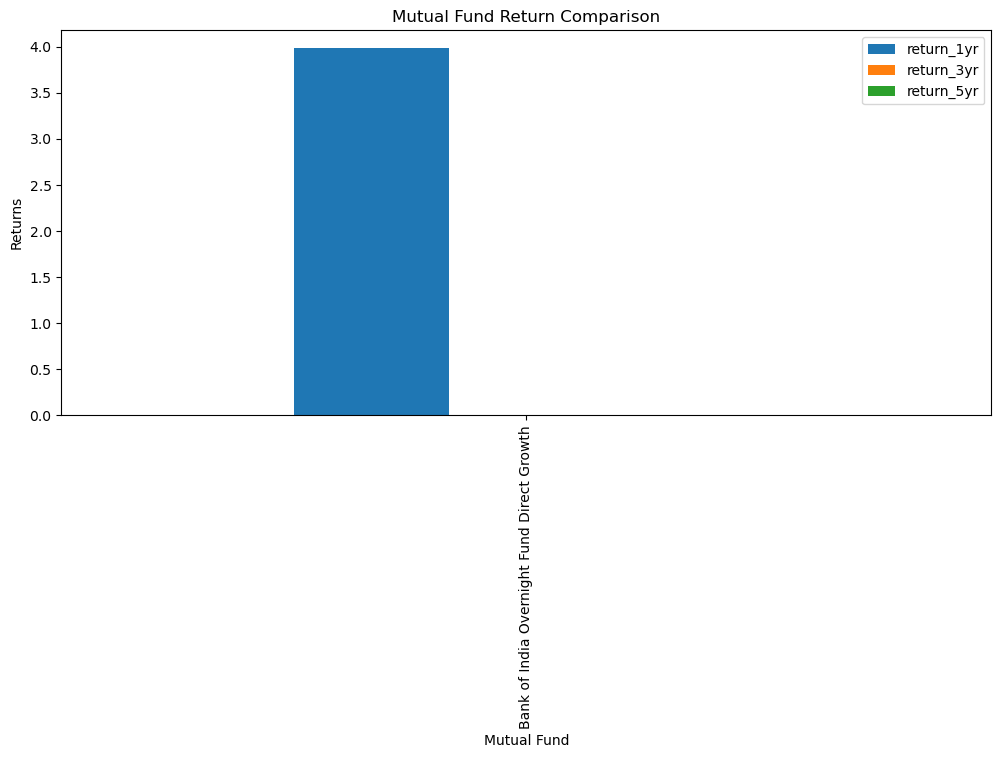

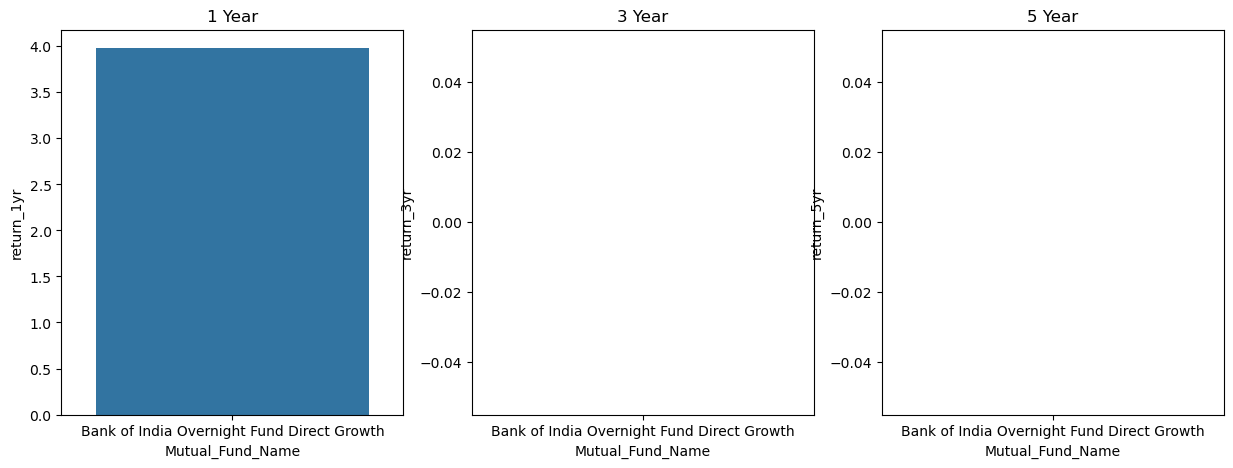

In [38]:
print(df.category.unique())
c = input("entery category type:")
ct = df[df.category == c]

print(ct.risk_type.unique())
r = input("enter risk type:")
rt = ct[ct.risk_type == r]

print(rt.AMC_name.unique())
amc = input("enter AMC name: ")
amcn = rt[rt.AMC_name == amc]


#GROUP BY
g = amcn.groupby("Mutual_Fund_Name")[["return_1yr","return_3yr","return_5yr"]].mean()


#BARPLOT
g.plot(kind="bar", figsize=(12,5))
plt.title("Mutual Fund Return Comparison")
plt.xlabel("Mutual Fund")
plt.ylabel("Returns")
plt.show()




#SUBPLOT
fig, ax = plt.subplots(1,3, figsize=(15,5))

sb.barplot(x=g.index, y=g["return_1yr"], ax=ax[0])
ax[0].set_title("1 Year")

sb.barplot(x=g.index, y=g["return_3yr"], ax=ax[1])
ax[1].set_title("3 Year")

sb.barplot(x=g.index, y=g["return_5yr"], ax=ax[2])
ax[2].set_title("5 Year")

plt.show()